{{ prolog }}

# MESMER-M workflow for emulating multiple scenarios

Using calibrated parameters, we can emulate a large ensemble of realisations of monthly near surface temperature with MESMER-M. To calibrate MESMER-M, follow the tutorials on calibrating multiple scenarios with MESMER-M in the Tutorial section. Here, we will emulate realisation for two scenarios at once. 

In [1]:
import pathlib

import cartopy.crs as ccrs
import filefisher
import matplotlib.pyplot as plt
import xarray as xr

import mesmer

## Configuration

In [2]:
# sampling parameters
NR_EMUS = 10
BUFFER = 20

In [3]:
# target model
model = "IPSL-CM6A-LR"

# scenarios used for training
scenarios = ["ssp126", "ssp585"]

# gridcells considered as land
THRESHOLD_LAND = 1 / 3

# reference period
REFERENCE_PERIOD = slice("1850", "1900")

# localisation radius for covariance matrix
LOCALISATION_RADII = list(range(7_500, 12_501, 500))

# mesmer provides example data under "./data/cmip6-ng"
cmip6_data_path = mesmer.example_data.cmip6_ng_path(relative=True)

# mesmer-m downscales annual temperature to
# monthly resolution

# variable, shared for input and output
variable = "tas"

# spatial resolution, shared for input and output
spatial_resolution = "g025"

# targeted temporal resolution
temporal_resolution_target = "mon"

# initial temporal resolution
temporal_resolution_initial = "ann"

## Load Input

We load annual mean temperatures using the library [*filefisher*](https://github.com/mpytools/filefisher)


In [4]:
CMIP_FILEFINDER = filefisher.FileFinder(
    path_pattern=cmip6_data_path / "{variable}/{time_res}/{resolution}",
    file_pattern="{variable}_{time_res}_{model}_{scenario}_{member}_{resolution}.nc",
)

We search for the intial (annaul) data for ssp126 and ssp585 as well as the corresponding historical data:

In [5]:
fc_scens_y = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario=scenarios,
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_initial,
    member="r1i1p1f1",
)

# get the historical members that
# are also in the future scenarios,
# but only once
unique_scen_members_y = fc_scens_y.df.member.unique()

fc_hist_y = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario="historical",
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_initial,
    member=unique_scen_members_y,
)

fc_all_y = fc_hist_y.concat(fc_scens_y)
fc_all_y.df

,variable,time_res,resolution,model,scenario,member
path,,,,,,
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_historical_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,historical,r1i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_ssp126_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,ssp126,r1i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_ssp585_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,ssp585,r1i1p1f1


We load the data using a helper function. For emulation, the historical and projection timeseries needs to be loaded in continously 

In [6]:
def _get_hist(meta, fc_hist):

    meta_hist = meta | {"scenario": "historical"}

    fc = fc_hist.search(**meta_hist)

    if len(fc) == 0:
        raise FileNotFoundError("no hist file found")
    if len(fc) != 1:
        raise ValueError("more than one hist file found")

    fN, meta_hist = fc[0]

    return fN, meta_hist


def load_hist(meta, fc_hist):
    fN, __ = _get_hist(meta, fc_hist)

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    return xr.open_dataset(fN, decode_times=time_coder)


def load_hist_scen_continuous(fc_hist, fc_scens):
    dt = xr.DataTree()
    for scen in fc_scens.df.scenario.unique():
        files = fc_scens.search(scenario=scen)

        members = []

        time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

        for fN, meta in files.items():

            try:
                hist = load_hist(meta, fc_hist)
            except FileNotFoundError:
                continue

            proj = xr.open_dataset(fN, decode_times=time_coder)

            ds = xr.combine_by_coords(
                [hist, proj],
                combine_attrs="override",
                data_vars="minimal",
                compat="override",
                coords="minimal",
            )

            ds = ds.drop_vars(("height", "time_bnds", "file_qf"), errors="ignore")

            # assign member-ID as coordinate
            ds = ds.assign_coords({"member": meta["member"]})

            members.append(ds)

        # create a Dataset that holds each member along the member dimension
        scen_data = xr.concat(members, dim="member")
        # put the scenario dataset into the DataTree
        dt[scen] = xr.DataTree(scen_data)
    return dt

In [7]:
tas_y_orig = load_hist_scen_continuous(fc_hist_y, fc_scens_y)

## Preprocessing the input data

### Calculate anomalies

In [8]:
ref = tas_y_orig.sel(time=REFERENCE_PERIOD).mean("time")
tas_anoms_y = tas_y_orig - ref

### Extract land gridcells & stack

In [9]:
def mask_and_stack(ds, threshold_land):
    ds = mesmer.mask.mask_ocean_fraction(ds, threshold_land)
    ds = mesmer.mask.mask_antarctica(ds)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

In [10]:
tas_y = mask_and_stack(tas_anoms_y, threshold_land=THRESHOLD_LAND)

## Load parameters

In [11]:
# find the parameters - use same relative path as above
data_path = pathlib.Path("./output/calibrated_parameters/mesmer-m")

PARAM_FILEFINDER = filefisher.FileFinder(
    path_pattern=data_path / "{esm}_{scen}",
    file_pattern="params_{module}_{esm}_{scen}.nc",
)

param_files = PARAM_FILEFINDER.find_files(esm=model)
param_files.df

,esm,scen,module
path,,,
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_covariance_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,covariance
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_grid-orig_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,grid-orig
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_harmonic-model_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,harmonic-model
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_local-variability_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,local-variability
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_m-time_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,m-time
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_m_time_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,m_time
output/calibrated_parameters/mesmer-m/IPSL-CM6A-LR_ssp126-ssp585/params_power-transformer_IPSL-CM6A-LR_ssp126-ssp585.nc,IPSL-CM6A-LR,ssp126-ssp585,power-transformer


In [12]:
all_modules = [
    "harmonic-model",
    "power-transformer",
    "local-variability",
    "covariance",
    "grid-orig",
    "m-time",
]

params = xr.DataTree()

for module in all_modules:
    params[module] = xr.DataTree(
        xr.open_dataset(param_files.search(module=module).paths.pop()), name=module
    )

## Draw emulations

Note: The mapping over xr.DataTree's does not natively work for the MESMER-M modules yet.

#### Random number seed

The `seed` determines the initial state for the random number generator. To avoid generating the same noise for different models and scenarios different seeds are required for each individual paring. For reproducibility the seed needs to be the same for any subsequent draw of the same emulator. To avoid human chosen standard seeds (e.g. `0`, `1234`) its recommended to also randomly generate the seeds and save them for later, using

```python
import secrets
secrets.randbits(128)

In [13]:
seed_local_variability = xr.DataTree.from_dict(
    {
        "ssp126": xr.Dataset(
            data_vars={"seed": 172968389139962348981869773740375508145}
        ),
        "ssp585": xr.Dataset(
            data_vars={"seed": 291080938549286612529980582809469521505}
        ),
    }
)

Extracting parameters

In [14]:
harmonic_coeffs = params["harmonic-model"].to_dataset()["coeffs"]
mtime_ds = params["m-time"].to_dataset()
time = mtime_ds["time"]

local_var_ds = params["local-variability"].to_dataset()
covariance = params["covariance"].to_dataset().localized_covariance

lambda_coeffs = params["power-transformer"].to_dataset()["lambda_coeffs"]

Loop over nodes

In [15]:
# Looping over nodes:
out = {}

for scen, node in tas_y.items():
    ds = node.to_dataset()
    tas = ds["tas"].sel(member="r1i1p1f1")

    seed = seed_local_variability[scen]

    # 1. harmonic model
    monthly_harmonic_emu = mesmer.stats.predict_harmonic_model(
        tas, harmonic_coeffs, mtime_ds
    )

    # 2. AR(1) variability
    local_variability_transformed = mesmer.stats.draw_auto_regression_monthly(
        local_var_ds,
        covariance,
        time=time,
        n_realisations=NR_EMUS,
        seed=seed,
        buffer=BUFFER,
    )

    # 3. inverse transform
    yj_transformer = mesmer.stats.YeoJohnsonTransformer("constant")
    local_variability_inverted = yj_transformer.inverse_transform(
        tas,
        local_variability_transformed.samples,
        lambda_coeffs,
    )

    # 4. combine
    emulations_node = monthly_harmonic_emu + local_variability_inverted.inverted

    out[scen] = emulations_node.to_dataset(name="tas")

# rebuild DataTree
emulations = xr.DataTree.from_dict(out)

In [16]:
for scen in emulations:
    local_seed = seed_local_variability[scen].seed.rename("seed_local_variability")
    emulations[scen] = xr.DataTree(xr.merge([emulations[scen].ds, local_seed]))

path = pathlib.Path("./output/emulations/mesmer-m/")
# uncomment to save emulations
# emulations.to_netcdf(path / f"tas_emulations_{model}_ssp126-ssp585.nc")

## Some example plots

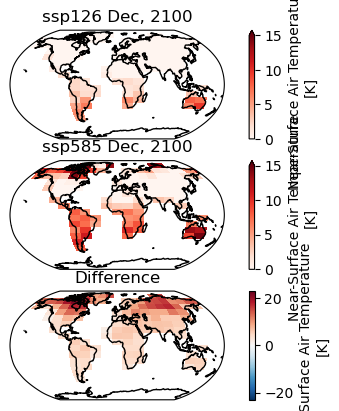

In [17]:
# maps of the means over all realisations for the two scenarios and their difference in 2100
grid_orig = params["grid-orig"].to_dataset()
spatial_emu_126 = mesmer.grid.unstack_lat_lon_and_align(
    emulations["ssp126"].tas, grid_orig
)
spatial_emu_585 = mesmer.grid.unstack_lat_lon_and_align(
    emulations["ssp585"].tas, grid_orig
)

f, axs = plt.subplots(3, 1, subplot_kw={"projection": ccrs.Robinson()})

opt = dict(cmap="Reds", transform=ccrs.PlateCarree(), vmin=0, vmax=15, extend="max")
spatial_emu_126.mean("realisation").isel(time=3011).plot(ax=axs[0], **opt)
spatial_emu_585.mean("realisation").isel(time=3011).plot(ax=axs[1], **opt)

diff = spatial_emu_585 - spatial_emu_126
diff.mean("realisation").isel(time=3011).plot(
    ax=axs[2], cmap="RdBu_r", transform=ccrs.PlateCarree(), center=0
)

axs[0].set_title("ssp126 Dec, 2100")
axs[1].set_title("ssp585 Dec, 2100")
axs[2].set_title("Difference")

for ax in axs:
    ax.coastlines()
    ax.set_global()

We can then visualize a random month of the emulated temperature fields - e.g. May 2000:

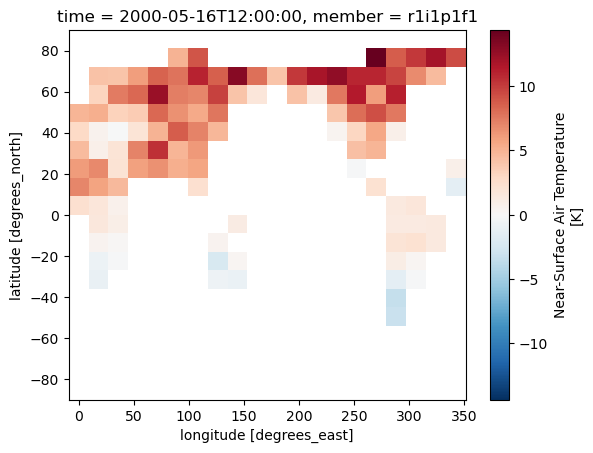

In [18]:
spatial_emu_585.isel(realisation=0).sel(time="2000-05").plot()

or compare the original monthly time series to our emulations.

In [19]:
# load original data
fc_scens_m = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario=scenarios,
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_target,
    member="r1i1p1f1",
)

# get the historical members that are also in the future scenarios, but only once
unique_scen_members_m = fc_scens_y.df.member.unique()

fc_hist_m = CMIP_FILEFINDER.find_files(
    variable="tas",
    scenario="historical",
    model=model,
    resolution="g025",
    time_res="mon",
    member=unique_scen_members_m,
)

fc_all_m = fc_hist_m.concat(fc_scens_m)
fc_all_m.df

tas_m_orig = load_hist_scen_continuous(fc_hist_m, fc_scens_m)

tas_anoms_m = tas_m_orig - ref

tas_m = mask_and_stack(tas_anoms_m, threshold_land=THRESHOLD_LAND)

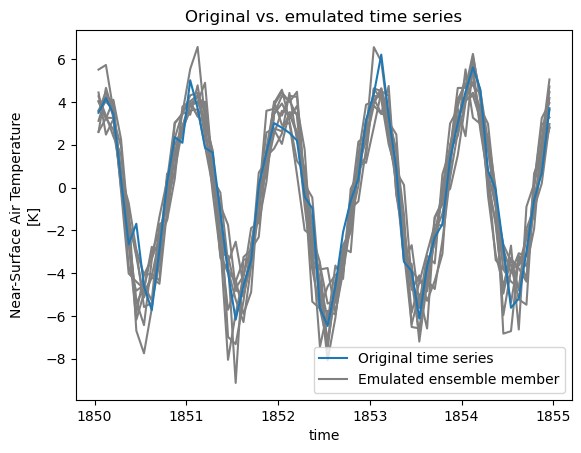

In [20]:
gridcell = 0
time_period = slice(None, 60)
scenario = "ssp585"

f, ax = plt.subplots()

# loop realisations
for i in range(10):
    d = emulations[scenario]["tas"].isel(
        gridcell=gridcell, realisation=i, time=time_period
    )
    d.plot(ax=ax, color="0.5")


# show original time series
d = tas_m[scenario]["tas"].sel(member="r1i1p1f1")
d["time"] = emulations[scenario]["time"]
d = d.isel(gridcell=gridcell, time=time_period)
d.plot(color="#1f78b4", label="Original time series")

# legend entry
ax.plot([], [], color="0.5", label="Emulated ensemble member")

ax.set_title("Original vs. emulated time series")

plt.legend()